# Pour comparer aux résultats du précédent stage

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyagrum.lib.notebook as gnb

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from algorithms.MIICAdapter import MIICAdapter
from algorithms.GHCBDeuAdapter import GHCBDeuAdapter
from algorithms.NOTEARSAdapter import NOTEARSAdapter
from algorithms.NOTEARSDiscreteAdapter import NOTEARSDiscreteAdapter
from algorithms.LiNGAMAdapter import LiNGAMAdapter
from pipeline.Dataset import Dataset
from pipeline.Structure import dag_to_structure
from metrics.SHDMetric import SHDMetric
from metrics.F1ScoreMetric import F1ScoreMetric
from metrics.TPRMetric import TPRMetric
from data.sachs.load_ground_truth import load_sachs_ground_truth
from preprocessing.hartemink import hartemink_discretize_multi
from notebooks.utils import cpdag_to_dot, plot_pairwise_heatmaps

/home/mathis/Documents/Travail/cbnsl_benchmark/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement des donnees

Dataset: 853 samples, 11 variables
Ground truth: 18 arcs, 0 edges

Golden BN DAG:


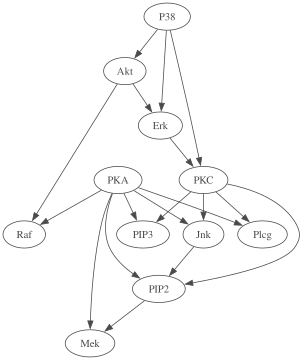

In [2]:
sachs_data = pd.read_csv(project_root / "data" / "sachs" / "sachs_observational.csv", sep="\t")
ground_truth = load_sachs_ground_truth(version="bn18", as_structure=True)

dataset = Dataset(
    sachs_data.to_numpy(),
    golden_structure=ground_truth,
    name="sachs_observational",
    feature_names=list(sachs_data.columns),
)

print(f"Dataset: {sachs_data.shape[0]} samples, {sachs_data.shape[1]} variables")
print(f"Ground truth: {ground_truth.cpdag.sizeArcs()} arcs, {ground_truth.cpdag.sizeEdges()} edges")
print("\nGolden BN DAG:")
gnb.showDot(cpdag_to_dot(ground_truth, dataset.feature_names))

## 2. Configuration

Hyperparamètres récupérés sur les figures du rapport

In [9]:
metrics = [SHDMetric(), F1ScoreMetric(), TPRMetric()]
metric_names = [m.name() for m in metrics]
objectives = {"SHD": True, "F1-Score": False, "TPR": False}
pareto_objectives = {"SHD": True, "F1-Score": False}

RANK_BY = "F1-Score"  # Pareto selection: choose which metric to prioritize "SHD" or "F1-Score"
VERBOSE = False # Verbosity: print grid search progress

# continuous lingam
lingam_threshold = 0.2

# continuous notears
cnt_notears_threshold = 0.3
cnt_notears_l1 = 0.147

# discrete notears
dis_notears_threshold = 0.8
dis_notears_l1 = 0.034
dis_notears_discretization = "hartemink"
dis_notears_init_bins = 40 # 100 # ou 1000 ? ce n'est pas précisé dans le rapport
dis_notears_n_bins = 2

# discrete miic
miic_discretization = "hartemink"
miic_init_bins = 40 # reel : 1000
miic_n_bins = 4


# discrete ghc
ghc_discretization = "hartemink"
ghc_init_bins = 40 # reel : 100
ghc_n_bins = 8

## 3. Exécution des algorithmes (learn_dag)

In [10]:
# Precompute Hartemink discretizations (one run per initial_bins, shared across adapters)
df = sachs_data
hartemink_precomputed = {}
# Group by initial_bins -> collect all n_bins needed
hartemink_configs = {
    dis_notears_init_bins: {dis_notears_n_bins},
    miic_init_bins: {miic_n_bins},
    ghc_init_bins: {ghc_n_bins},
}
# Merge sets for same initial_bins
groups = {}
for ib, nbs in hartemink_configs.items():
    groups.setdefault(ib, set()).update(nbs)

for initial_bins, n_bins_set in groups.items():
    results = hartemink_discretize_multi(df, sorted(n_bins_set), initial_bins=initial_bins, progress=True)
    for nb, disc_df in results.items():
        hartemink_precomputed[(nb, initial_bins)] = disc_df

algos = {
    "LiNGAM": LiNGAMAdapter(threshold=lingam_threshold),
    "NOTEARS": NOTEARSAdapter(lambda1=cnt_notears_l1, w_threshold=cnt_notears_threshold),
    "NOTEARS Disc.": NOTEARSDiscreteAdapter(
        lambda1=dis_notears_l1, w_threshold=dis_notears_threshold,
        n_bins=dis_notears_n_bins, discretization_method=dis_notears_discretization,
        initial_bins=dis_notears_init_bins,
        discretized_df=hartemink_precomputed.get((dis_notears_n_bins, dis_notears_init_bins)),
    ),
    "MIIC": MIICAdapter(
        n_bins=miic_n_bins, discretization_method=miic_discretization,
        initial_bins=miic_init_bins,
        discretized_df=hartemink_precomputed.get((miic_n_bins, miic_init_bins)),
    ),
    "GHC+BDeu": GHCBDeuAdapter(
        n_bins=ghc_n_bins, discretization_method=ghc_discretization,
        initial_bins=ghc_init_bins,
        discretized_df=hartemink_precomputed.get((ghc_n_bins, ghc_init_bins)),
    ),
}

# Run learn_dag and wrap in Structure for metric compatibility
structures = {}
for name, algo in algos.items():
    dag = algo.learn_dag(dataset)
    structures[name] = dag_to_structure(dag)
    print(f"{name}: {dag.sizeArcs()} arcs")

print("Done.")

Hartemink merging: 100%|██████████| 352/352 [01:53<00:00,  3.10it/s]


LiNGAM: 7 arcs
NOTEARS: 14 arcs
NOTEARS Disc.: 0 arcs
MIIC: 7 arcs
GHC+BDeu: 5 arcs
Done.


## 4. Métriques par algorithme (vs Golden BN)

In [11]:
metrics = [SHDMetric(), F1ScoreMetric(), TPRMetric()]
objectives = {"SHD": True, "F1-Score": False, "TPR": False}

# Compute metrics for each algorithm vs golden BN
rows = []
for name, structure in structures.items():
    row = {"Algorithm": name}
    for metric in metrics:
        row[metric.name()] = metric.compute(ref=ground_truth, test=structure)
    rows.append(row)

results_df = pd.DataFrame(rows).set_index("Algorithm")
results_df

,SHD,F1-Score,TPR
Algorithm,,,
LiNGAM,20.0,0.000000,0.000000
NOTEARS,24.0,0.074074,0.076923
NOTEARS Disc.,18.0,0.000000,0.000000
MIIC,20.0,0.240000,0.166667
GHC+BDeu,18.0,0.181818,0.117647


## 5. DAGs appris

Golden BN DAG (18 arcs):


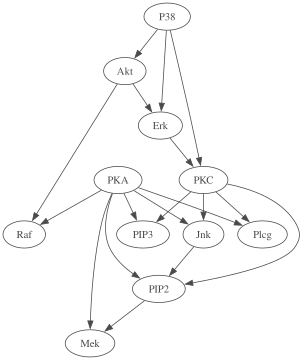


LiNGAM — 7 arcs


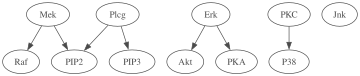


NOTEARS — 14 arcs


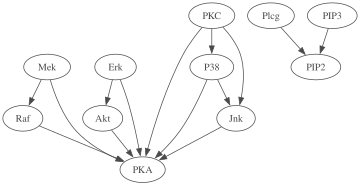


NOTEARS Disc. — 0 arcs



MIIC — 7 arcs


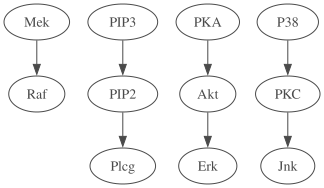


GHC+BDeu — 5 arcs


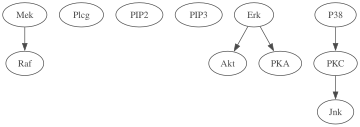

In [12]:
feature_names = dataset.feature_names

print(f"Golden BN DAG ({ground_truth.cpdag.sizeArcs()} arcs):")
gnb.showDot(cpdag_to_dot(ground_truth, feature_names))

for name, structure in structures.items():
    print(f"\n{name} — {structure.cpdag.sizeArcs()} arcs")
    gnb.showDot(cpdag_to_dot(structure, feature_names))

## 6. Scatter SHD vs F1-Score

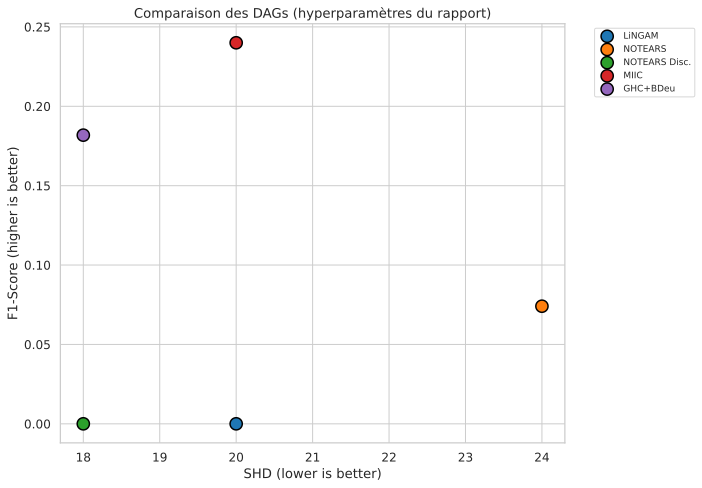

In [13]:
algo_names = list(structures.keys())
palette = sns.color_palette("tab10", len(algo_names))

fig, ax = plt.subplots(figsize=(10, 7))
for idx, name in enumerate(algo_names):
    row = results_df.loc[name]
    ax.scatter(
        row["SHD"], row["F1-Score"],
        color=palette[idx], s=150, edgecolors="black", linewidths=1.5,
        label=name, zorder=5,
    )
ax.set_xlabel("SHD (lower is better)")
ax.set_ylabel("F1-Score (higher is better)")
ax.set_title("Comparaison des DAGs (hyperparamètres du rapport)")
ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Heatmaps pairwise

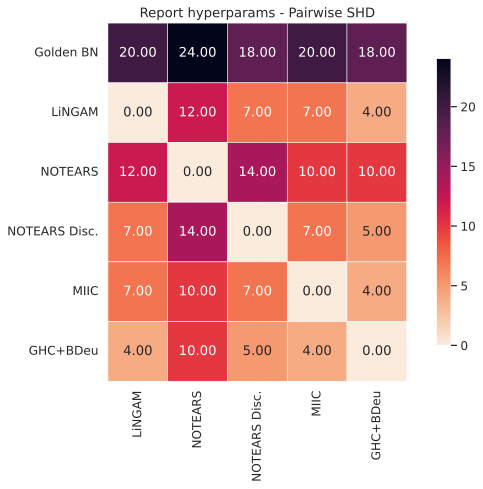

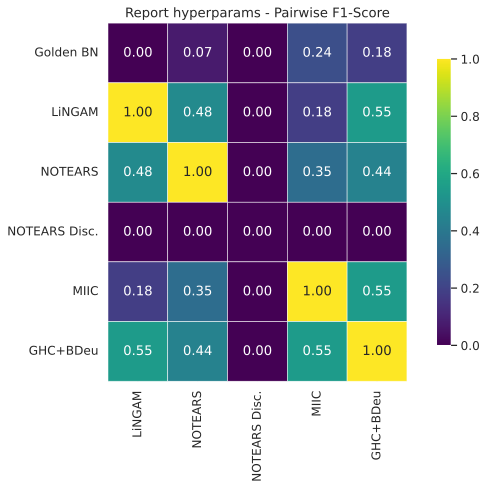

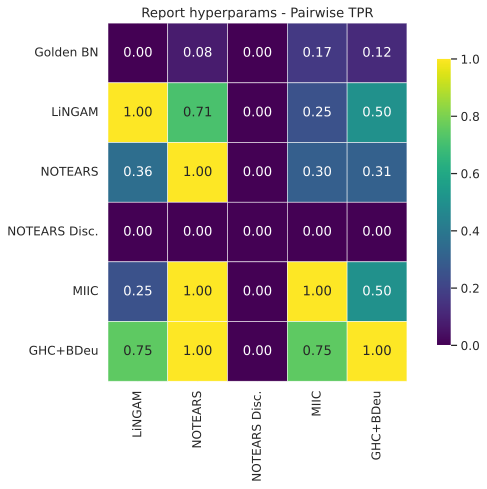

In [14]:
plot_pairwise_heatmaps(structures, "Report hyperparams", metrics, objectives, golden_structure=ground_truth)